# Exercise 02 — Save or Let Go Starter Notebook

> **Graded, multiweek exercise.** This is not the short in-class Guided Practice notebook. Save your own copy and continue it across Weeks 4–6.

The exercise progresses through the same retention decision:

1. **Week 4 checkpoint — build the probability model:** inspect relationships; fit one-input, two-input, and full-feature logistic models; validate the baseline.
2. **Week 5 checkpoint A — regularize the model:** redo the full model with Ridge and Lasso while holding rows, preprocessing, folds, and metrics fixed.
3. **Week 5 checkpoint B — build the policy:** use campaign economics, contact capacity, and sensitivity analysis to choose a threshold.
4. **Week 6 checkpoint — compare and recommend:** add a tree-based candidate and finalize the model-and-policy recommendation.

Use **File → Save a copy in Drive** before editing. Stop at each checkpoint and record your reasoning, not only the output.


## Before you run anything

**Prediction question:** What is the probability that a customer will churn?

**Decision question:** Which customers should receive a retention contact, given limited capacity and campaign costs?

The model produces a probability. A threshold and the campaign assumptions turn that probability into an action.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42


## Load the data

The loader first looks for a local repository checkout. In Colab, it reads the same files directly from the public GitHub repository, so no authorization step should be required.


In [2]:
LOCAL_DATA = Path("../data")
RAW_BASE = "https://raw.githubusercontent.com/lathrahul/modern-ai-ml-exercises/main/exercise-02-retention/data"

def read_course_csv(filename):
    local_file = LOCAL_DATA / filename
    source = local_file if local_file.exists() else f"{RAW_BASE}/{filename}"
    return pd.read_csv(source)

train = read_course_csv("train.csv")
test = read_course_csv("test.csv")
costs = read_course_csv("campaign_costs.csv")

print("train:", train.shape, "test:", test.shape)
train.head()


train: (5282, 21) test: (1761, 20)


,customer_id,gender,senior_citizen,has_partner,has_dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churned
0,CUST-106215,Female,1,Yes,No,26,Yes,No,DSL,No,...,Yes,No,No,Yes,One year,No,Mailed check,60.85,1596.68,0
1,CUST-103122,Female,0,Yes,Yes,46,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,19.01,865.11,0
2,CUST-105353,Male,0,No,Yes,7,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.06,139.14,0
3,CUST-100969,Male,0,Yes,No,68,Yes,No,DSL,Yes,...,Yes,No,No,Yes,Two year,No,Bank transfer (automatic),70.97,4742.30,0
4,CUST-102279,Female,0,No,No,7,Yes,No,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Electronic check,61.52,439.81,0


# Week 4 checkpoint — Look first

Correlation is a descriptive starting point. It tells us whether two numeric variables move together in this sample. It does **not** produce a churn probability, control for other variables, or establish causality.

Because `churned` is coded 0/1, its Pearson correlation with a numeric feature is also the point-biserial correlation.


,tenure_months,monthly_charges,total_charges,senior_citizen,churned
tenure_months,1.00,0.24,0.82,0.02,-0.35
monthly_charges,0.24,1.00,0.65,0.22,0.20
total_charges,0.82,0.65,1.00,0.10,-0.19
senior_citizen,0.02,0.22,0.10,1.00,0.15
churned,-0.35,0.20,-0.19,0.15,1.00


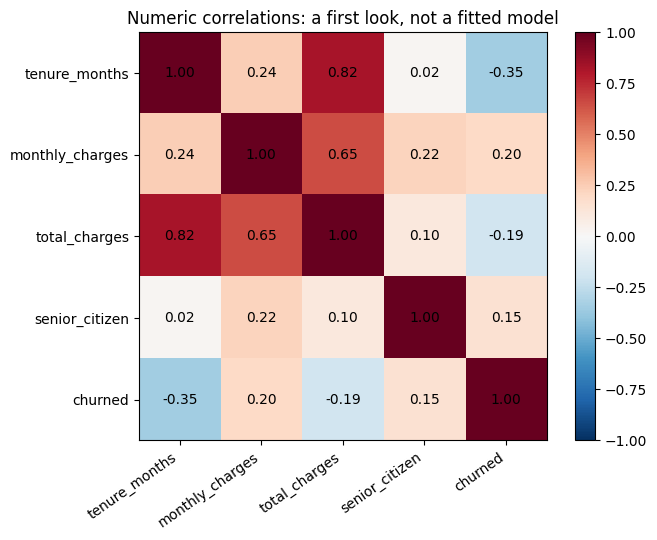

In [3]:
target = "churned"
numeric_for_corr = ["tenure_months", "monthly_charges", "total_charges", "senior_citizen", target]
corr = train[numeric_for_corr].corr()

display(corr.round(2))

fig, ax = plt.subplots(figsize=(7, 5.5))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=35, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title("Numeric correlations: a first look, not a fitted model")
plt.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


### Discuss 1 — read the correlations

1. Which numeric variable has the strongest relationship with churn?
2. What can this table tell us?
3. What can it **not** tell us that logistic regression can?


,churn_rate,customers
contract,,
Two year,2.7%,1272
One year,10.9%,1121
Month-to-month,43.1%,2889


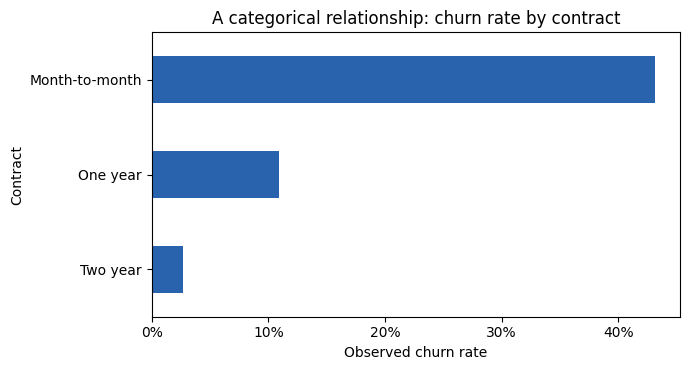

In [4]:
contract_rates = (
    train.groupby("contract", observed=True)[target]
    .agg(churn_rate="mean", customers="size")
    .sort_values("churn_rate")
)
display(contract_rates.style.format({"churn_rate": "{:.1%}"}))

ax = contract_rates["churn_rate"].plot(kind="barh", color="#2a63ad", figsize=(7, 3.8))
ax.set_xlabel("Observed churn rate")
ax.set_ylabel("Contract")
ax.set_title("A categorical relationship: churn rate by contract")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()


# Week 4 checkpoint — Build ordinary logistic regression slowly

**Goal:** see what logistic regression adds beyond correlation, then finish with a working baseline you can evaluate.

We will compare one-input, two-input, and full-feature models; interpret coefficients as changes in odds; evaluate all models on the same validation rows; and use stratified K-fold cross-validation rather than depending on one split.


## 1. Prevalence and the simple baseline

If the churn rate is low, a model can have high accuracy by predicting that everyone stays. That is why accuracy alone is not enough.


,value
churn prevalence,26.5%
always-stay accuracy,73.5%


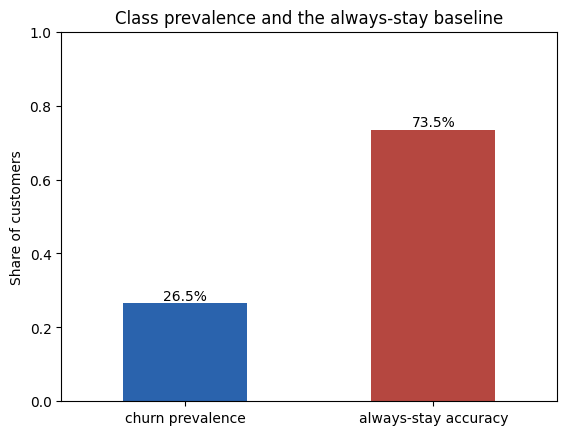

In [5]:
target = "churned"
prevalence = train[target].mean()
always_stay_accuracy = 1 - prevalence

summary = pd.Series({
    "churn prevalence": prevalence,
    "always-stay accuracy": always_stay_accuracy,
})
display(summary.to_frame("value").style.format("{:.1%}"))

ax = summary.plot(kind="bar", color=["#2a63ad", "#b54740"], ylim=(0, 1), rot=0)
ax.set_ylabel("Share of customers")
ax.set_title("Class prevalence and the always-stay baseline")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


### Discuss 2 — establish the baseline

1. What would accuracy report for the always-stay rule?
2. What does that number fail to tell us about customers who actually churn?


## 2. Train, validation, and test are different roles

- **Training rows** are used to learn preprocessing and coefficients.
- **Validation rows** estimate performance and help us compare choices.
- **Test rows** should remain untouched until the policy is finalized.

Stratification keeps approximately the same churn prevalence on both sides of this first split.


In [6]:
X = train.drop(columns=[target, "customer_id"])
y = train[target]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

pd.DataFrame({
    "rows": [len(y_train), len(y_valid)],
    "churn rate": [y_train.mean(), y_valid.mean()],
}, index=["train", "validation"])


,rows,churn rate
train,3961,0.265337
validation,1321,0.265708


## 3. Model A — one input

Start with `tenure_months`. Before fitting, predict the coefficient sign:

- positive means longer tenure raises the odds of churn;
- negative means longer tenure lowers the odds of churn.

The odds multiplier for one additional month is $e^{β}$.


tenure coefficient: -0.038
odds multiplier for one additional month: 0.963


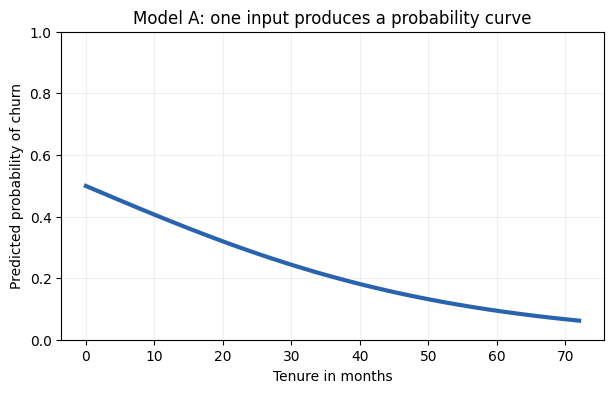

In [7]:
one_features = ["tenure_months"]

one_input_model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(C=1e6, max_iter=2000, random_state=RANDOM_STATE)),
])
one_input_model.fit(X_train[one_features], y_train)

beta_tenure = one_input_model.named_steps["model"].coef_[0, 0]
print(f"tenure coefficient: {beta_tenure:.3f}")
print(f"odds multiplier for one additional month: {np.exp(beta_tenure):.3f}")

tenure_grid = pd.DataFrame({"tenure_months": np.arange(0, 73)})
tenure_probability = one_input_model.predict_proba(tenure_grid)[:, 1]
plt.figure(figsize=(7, 4))
plt.plot(tenure_grid["tenure_months"], tenure_probability, color="#2a63ad", linewidth=3)
plt.xlabel("Tenure in months")
plt.ylabel("Predicted probability of churn")
plt.ylim(0, 1)
plt.title("Model A: one input produces a probability curve")
plt.grid(alpha=0.2)
plt.show()


### Discuss 3 — coefficient, odds, probability

1. Does the coefficient sign match the correlation sign?
2. Does the odds multiplier describe odds or probability?
3. Is the change in probability constant across the whole curve?


## 4. Model B — add a second input

Now add `monthly_charges`. Each coefficient answers a conditional question: how does one input relate to churn **while the other included input stays fixed**?


In [8]:
two_features = ["tenure_months", "monthly_charges"]
two_input_model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(C=1e6, max_iter=2000, random_state=RANDOM_STATE)),
])
two_input_model.fit(X_train[two_features], y_train)

two_coef = pd.DataFrame({
    "coefficient": two_input_model.named_steps["model"].coef_.ravel(),
}, index=two_features)
two_coef["odds multiplier for one unit"] = np.exp(two_coef["coefficient"])
display(two_coef.round(3))

example_customers = pd.DataFrame({
    "tenure_months": [6, 6, 48, 48],
    "monthly_charges": [35, 90, 35, 90],
})
example_customers["predicted churn probability"] = two_input_model.predict_proba(example_customers)[:, 1]
display(example_customers.style.format({"predicted churn probability": "{:.1%}"}))


,coefficient,odds multiplier for one unit
tenure_months,-0.053,0.949
monthly_charges,0.031,1.032


,tenure_months,monthly_charges,predicted churn probability
0,6,35,28.1%
1,6,90,68.5%
2,48,35,4.1%
3,48,90,19.1%


### Discuss 4 — what changed after adding a variable?

1. Compare customers with the same tenure and different monthly charges.
2. Compare customers with the same monthly charges and different tenure.
3. Why can a coefficient change after another variable enters the model?


## 5. Model C — use the full feature set safely

Scaling, imputation, and category encoding learn values from data. Keeping them inside the pipeline ensures that each fit learns only from its training rows.


In [9]:
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("numeric", numeric_pipe, numeric_features),
    ("categorical", categorical_pipe, categorical_features),
])

baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(C=1e6, max_iter=2000, random_state=RANDOM_STATE)),
])

baseline_model


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['senior_citizen',
                                                   'tenure_months',
                                                   'monthly_charges',
                                                   'total_charges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'has_partner',
                                                   'has_dependents',
                                                   'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streaming_tv',
                                                   'streaming_movies',
                                                   'contract',
                                                   'paperless_billing',
                                                   'payment_method'])])),
                ('model',
                 LogisticRegression(C=1000000.0, max_iter=2000,
                                    random_state=42))])

## 6. Compare Models A, B, and C on the same validation customers

The comparison changes only the feature set. The validation rows and metrics stay fixed.


,accuracy @ 0.50,log loss,ROC-AUC,PR-AUC
Model A: tenure only,0.734,0.503,0.751,0.495
Model B: tenure + charges,0.796,0.437,0.827,0.640
Model C: full feature set,0.815,0.399,0.862,0.683


,validation result
log loss (lower is better),0.399
ROC-AUC,0.862
PR-AUC,0.683


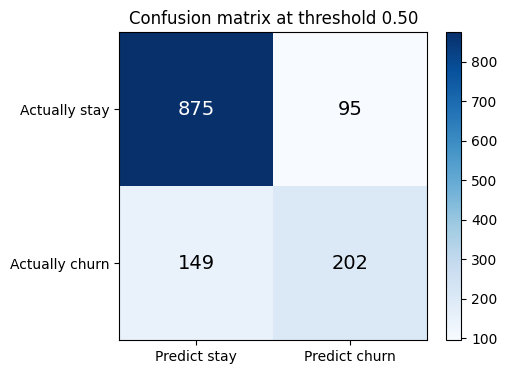

In [10]:
baseline_model.fit(X_train, y_train)
valid_probability = baseline_model.predict_proba(X_valid)[:, 1]

one_probability = one_input_model.predict_proba(X_valid[one_features])[:, 1]
two_probability = two_input_model.predict_proba(X_valid[two_features])[:, 1]

def probability_metrics(actual, probability):
    prediction = (probability >= 0.50).astype(int)
    return {
        "accuracy @ 0.50": accuracy_score(actual, prediction),
        "log loss": log_loss(actual, probability),
        "ROC-AUC": roc_auc_score(actual, probability),
        "PR-AUC": average_precision_score(actual, probability),
    }

model_comparison = pd.DataFrame({
    "Model A: tenure only": probability_metrics(y_valid, one_probability),
    "Model B: tenure + charges": probability_metrics(y_valid, two_probability),
    "Model C: full feature set": probability_metrics(y_valid, valid_probability),
}).T
display(model_comparison.round(3))

metrics = pd.Series({
    "log loss (lower is better)": log_loss(y_valid, valid_probability),
    "ROC-AUC": roc_auc_score(y_valid, valid_probability),
    "PR-AUC": average_precision_score(y_valid, valid_probability),
})
display(metrics.to_frame("validation result").round(3))

threshold = 0.50
valid_prediction = (valid_probability >= threshold).astype(int)
cm = confusion_matrix(y_valid, valid_prediction)

fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Predict stay", "Predict churn"])
ax.set_yticks([0, 1], labels=["Actually stay", "Actually churn"])
ax.set_title(f"Confusion matrix at threshold {threshold:.2f}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()


### Discuss 5 — evaluate the baseline model

1. Which metric answers “Are the probabilities numerically useful?”
2. Which error in the confusion matrix represents a customer who churned but was not contacted?
3. Change `threshold` from `0.50` to `0.30` and rerun only the confusion-matrix cell. What moves?


## 7. Why cross-validation?

One validation split may be unusually easy or difficult. In five-fold cross-validation, each fold serves as validation once while the other four folds train the complete pipeline.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "neg_log_loss": "neg_log_loss",
}

cv_result = cross_validate(baseline_model, X, y, cv=cv, scoring=scoring)
fold_results = pd.DataFrame({
    "ROC-AUC": cv_result["test_roc_auc"],
    "PR-AUC": cv_result["test_pr_auc"],
    "log loss": -cv_result["test_neg_log_loss"],
}, index=[f"fold {i}" for i in range(1, 6)])

display(fold_results.round(3))
display(pd.DataFrame({"mean": fold_results.mean(), "std": fold_results.std()}).round(3))


,ROC-AUC,PR-AUC,log loss
fold 1,0.833,0.619,0.432
fold 2,0.836,0.623,0.429
fold 3,0.837,0.658,0.427
fold 4,0.864,0.700,0.397
fold 5,0.854,0.652,0.406


,mean,std
ROC-AUC,0.845,0.014
PR-AUC,0.650,0.032
log loss,0.418,0.016


### Week 4 checkpoint — explain the complete baseline

In two or three sentences, record:

- what correlation showed before fitting a model;
- what changed from Model A to Model B to Model C;
- why the five-fold mean and spread are more informative than one validation score.


# Bridge to Week 5 — two meanings of iteration

Models A, B, and C were **modeling iterations**: we changed the feature set and compared each specification on the same validation customers.

| Modeling iteration | Inputs | Validation log loss |
|---|---|---:|
| Model A | tenure | 0.503 |
| Model B | tenure + monthly charges | 0.437 |
| Model C | full feature set | 0.399 |

Lower validation log loss means the probabilities were numerically better on these validation rows. Model C did not win because its solver simply ran for more steps.

Within one fixed model, the solver also performs **optimizer iterations**. It repeatedly updates the coefficients to reduce the training objective. The next cell makes those updates visible for Model B.


,optimizer iteration,training log loss,validation log loss
0,0,0.693,0.693
1,1,0.653,0.651
2,2,0.622,0.618
3,5,0.561,0.555
4,10,0.515,0.505
5,20,0.483,0.468
6,50,0.464,0.444
7,100,0.461,0.438
8,200,0.461,0.437


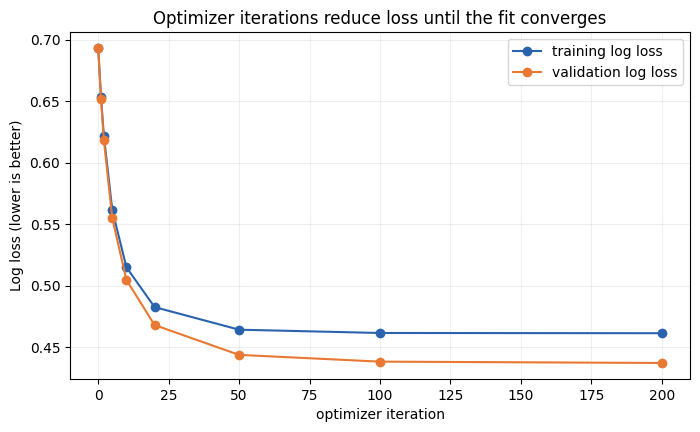

In [12]:
# A transparent batch-gradient-descent demonstration for Model B.
# This is for learning; scikit-learn uses a faster numerical solver.
iteration_features = ["tenure_months", "monthly_charges"]
iteration_scaler = StandardScaler()
X_iteration_train = iteration_scaler.fit_transform(X_train[iteration_features])
X_iteration_valid = iteration_scaler.transform(X_valid[iteration_features])

# Add a column of ones for the intercept.
X_iteration_train = np.column_stack([np.ones(len(X_iteration_train)), X_iteration_train])
X_iteration_valid = np.column_stack([np.ones(len(X_iteration_valid)), X_iteration_valid])

beta = np.zeros(X_iteration_train.shape[1])
learning_rate = 0.50
checkpoints = [0, 1, 2, 5, 10, 20, 50, 100, 200]
history = []

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

for iteration in range(201):
    if iteration in checkpoints:
        train_p = sigmoid(X_iteration_train @ beta)
        valid_p = sigmoid(X_iteration_valid @ beta)
        history.append({
            "optimizer iteration": iteration,
            "training log loss": log_loss(y_train, train_p),
            "validation log loss": log_loss(y_valid, valid_p),
        })
    if iteration < 200:
        train_p = sigmoid(X_iteration_train @ beta)
        gradient = X_iteration_train.T @ (train_p - y_train.to_numpy()) / len(y_train)
        beta -= learning_rate * gradient

iteration_history = pd.DataFrame(history)
display(iteration_history.round(3))

ax = iteration_history.plot(
    x="optimizer iteration",
    y=["training log loss", "validation log loss"],
    marker="o",
    color=["#2a63ad", "#e87832"],
    figsize=(8, 4.5),
)
ax.set_ylabel("Log loss (lower is better)")
ax.set_title("Optimizer iterations reduce loss until the fit converges")
ax.grid(alpha=0.2)
plt.show()


### Read the iteration curve

- Early coefficient updates reduce both training and validation log loss in this example.
- The improvements become very small as the solver converges.
- `max_iter` sets a ceiling on solver work. Increase it when the model has not converged; do not treat it as a generalization control.
- Validation log loss is not guaranteed to improve whenever training log loss improves.
- Regularization comes next because it changes the objective and the final coefficient solution, especially when the full feature set contains correlated signals.


# Week 5 checkpoint A — Redo Model C with Ridge and Lasso

**Goal:** compare three penalty choices while keeping the feature set, split logic, preprocessing, and metrics fixed.

- The near-unpenalized model provides the baseline.
- **Ridge (L2)** shrinks correlated signals and usually keeps all coefficients.
- **Lasso (L1)** can set some coefficients exactly to zero.

`C` is the inverse of regularization strength in scikit-learn: a smaller `C` means stronger shrinkage.


In [13]:
models = {
    "near-unpenalized": LogisticRegression(C=1e6, max_iter=2000, random_state=RANDOM_STATE),
    "Ridge (L2)": LogisticRegression(penalty="l2", C=0.20, max_iter=2000, random_state=RANDOM_STATE),
    "Lasso (L1)": LogisticRegression(penalty="l1", solver="liblinear", C=0.20, max_iter=2000, random_state=RANDOM_STATE),
}

comparison_rows = []
fitted_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
    result = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    comparison_rows.append({
        "model": name,
        "ROC-AUC mean": result["test_roc_auc"].mean(),
        "ROC-AUC std": result["test_roc_auc"].std(),
        "PR-AUC mean": result["test_pr_auc"].mean(),
        "log loss mean": -result["test_neg_log_loss"].mean(),
    })
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

comparison = pd.DataFrame(comparison_rows).set_index("model")
display(comparison.round(3))

print("Read this as a redo of Model C: the inputs and evaluation stay fixed; only the penalty changes.")


,ROC-AUC mean,ROC-AUC std,PR-AUC mean,log loss mean
model,,,,
near-unpenalized,0.845,0.012,0.650,0.418
Ridge (L2),0.844,0.012,0.651,0.418
Lasso (L1),0.844,0.011,0.651,0.419


Read this as a redo of Model C: the inputs and evaluation stay fixed; only the penalty changes.


## Inspect what happened to the coefficients

The chart compares the largest coefficients after preprocessing. A positive coefficient increases log-odds of churn; a negative coefficient decreases them, holding the other encoded inputs fixed.


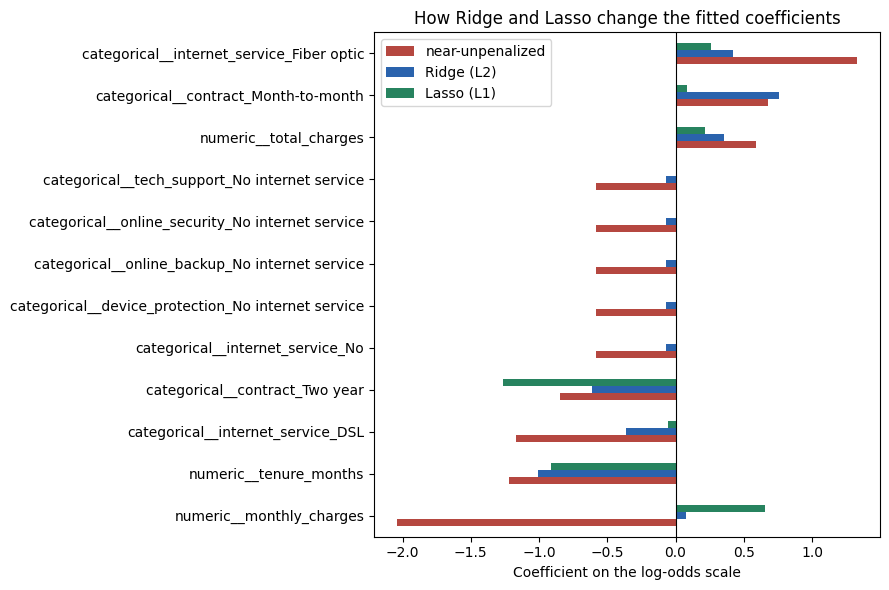

,coefficients equal to zero
near-unpenalized,0
Ridge (L2),0
Lasso (L1),18


In [14]:
feature_names = fitted_pipelines["near-unpenalized"].named_steps["preprocess"].get_feature_names_out()
coef_frame = pd.DataFrame(index=feature_names)

for name, pipe in fitted_pipelines.items():
    coef_frame[name] = pipe.named_steps["model"].coef_.ravel()

top_features = coef_frame["near-unpenalized"].abs().nlargest(12).index
plot_data = coef_frame.loc[top_features].sort_values("near-unpenalized")
plot_data.plot(kind="barh", figsize=(9, 6), color=["#b54740", "#2a63ad", "#27835f"])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient on the log-odds scale")
plt.title("How Ridge and Lasso change the fitted coefficients")
plt.tight_layout()
plt.show()

zero_counts = (coef_frame.abs() < 1e-10).sum().rename("coefficients equal to zero")
zero_counts.to_frame()


### Week 5 checkpoint A — compare the redo

Record short answers:

1. Which model produces the most exact zeros?
2. Did regularization materially change mean validation performance?
3. If two models perform similarly, what practical reason might favor Ridge, Lasso, or the simpler baseline?

Do not claim that a zero Lasso coefficient proves a feature is unimportant. Correlated features can exchange which signal is retained.


# Week 5 checkpoint B — From churn probabilities to a retention policy

The model estimates risk. The operating policy decides whom to contact. Use the supplied campaign assumptions, a contact-capacity limit, and sensitivity analysis rather than selecting a threshold from accuracy alone.

For this checkpoint, use the Ridge validation probabilities as a defensible working candidate. You may replace the model later if your Week 6 comparison supports a different choice.


In [15]:
# Use validation probabilities from the already-fitted Ridge model.
ridge_probability = fitted_pipelines["Ridge (L2)"].predict_proba(X_valid)[:, 1]

assumptions = costs.set_index("parameter")["value_usd_or_rate"].to_dict()
contact_cost = assumptions["contact_cost"]
offer_cost = assumptions["offer_cost_if_accepted"]
gross_margin_saved = assumptions["gross_margin_saved"]
acceptance_rate = assumptions["offer_acceptance_rate"]
success_rate = assumptions["intervention_success_rate"]

# A planning constraint: the team can contact at most 20% of validation customers.
capacity = int(np.floor(0.20 * len(y_valid)))

def threshold_table(probability, actual, margin_multiplier=1.0):
    rows = []
    for threshold in np.arange(0.10, 0.81, 0.05):
        contact = probability >= threshold
        true_churn_contacted = ((actual.to_numpy() == 1) & contact).sum()
        expected_saved = true_churn_contacted * acceptance_rate * success_rate * gross_margin_saved * margin_multiplier
        expected_spend = contact.sum() * (contact_cost + acceptance_rate * offer_cost)
        rows.append({
            "threshold": threshold,
            "contacts": int(contact.sum()),
            "within capacity": bool(contact.sum() <= capacity),
            "expected campaign value": expected_saved - expected_spend,
        })
    return pd.DataFrame(rows)

policy = threshold_table(ridge_probability, y_valid)
display(policy.style.format({"threshold": "{:.2f}", "expected campaign value": "${:,.0f}"}))

feasible = policy[policy["within capacity"]]
selected = feasible.loc[feasible["expected campaign value"].idxmax()]
print(f"Capacity: {capacity} contacts")
print(f"Best listed feasible threshold: {selected['threshold']:.2f}")


,threshold,contacts,within capacity,expected campaign value
0,0.10,818,False,"$4,999"
1,0.15,710,False,"$6,702"
2,0.20,619,False,"$7,704"
3,0.25,554,False,"$8,488"
4,0.30,483,False,"$9,112"
5,0.35,427,False,"$9,088"
6,0.40,383,False,"$8,901"
7,0.45,336,False,"$8,715"
8,0.50,291,False,"$8,151"
9,0.55,238,True,"$7,642"


Capacity: 264 contacts
Best listed feasible threshold: 0.55


## Week 5 sensitivity check

Campaign assumptions are estimates. Recalculate the policy if the saved margin is only 40% of the planning value. If the selected threshold changes, the policy is sensitive to that assumption and should be monitored closely.


In [16]:
sensitivity = threshold_table(ridge_probability, y_valid, margin_multiplier=0.40)
display(sensitivity.style.format({"threshold": "{:.2f}", "expected campaign value": "${:,.0f}"}))

feasible_sensitivity = sensitivity[sensitivity["within capacity"]]
selected_sensitivity = feasible_sensitivity.loc[feasible_sensitivity["expected campaign value"].idxmax()]
print(f"Best listed feasible threshold under lower saved margin: {selected_sensitivity['threshold']:.2f}")


,threshold,contacts,within capacity,expected campaign value
0,0.10,818,False,"$-11,252"
1,0.15,710,False,"$-8,821"
2,0.20,619,False,"$-6,946"
3,0.25,554,False,"$-5,579"
4,0.30,483,False,"$-4,180"
5,0.35,427,False,"$-3,282"
6,0.40,383,False,"$-2,644"
7,0.45,336,False,"$-1,957"
8,0.50,291,False,"$-1,454"
9,0.55,238,True,$-799


Best listed feasible threshold under lower saved margin: 0.75


### Week 5 checkpoint B — record the policy

1. State the regularized model you are carrying forward and why.
2. State the selected threshold, expected contacts, and expected campaign value.
3. Explain whether the 40%-margin sensitivity scenario changes the threshold.
4. Name one subgroup or operational constraint you will check before the final recommendation.

## Week 6 continuation

Add a tree or Random Forest using the same validation design. Then compare probability quality, threshold economics, subgroup performance, and interpretability before creating `submission.csv`.


In [17]:
# Week 6 final-output template (leave commented until a final model and threshold are chosen)
# probabilities = final_model.predict_proba(test.drop(columns="customer_id"))[:, 1]
# threshold = ...
# submission = pd.DataFrame({
#     "customer_id": test["customer_id"],
#     "churn_probability": probabilities,
#     "contact_customer": (probabilities >= threshold).astype(int),
# })
# submission.to_csv("../submission.csv", index=False)


## Generative AI use disclosure

Complete the disclosure specified in `../../shared/ai_use_disclosure.md`. Record how AI was used, what you verified, and what decisions remain your own.
